# Load data

In [10]:
import pandas as pd

rbp = 'PABPC1'
rmats_folder =f'N:/Splicing/RBP_signaling/MATS_GencodeV29/HepG2/{rbp}/'
event_type = 'SE'
junction_type = 'JCEC'

alpha = 0.05
min_dpsi = 0.2

data = pd.read_csv(f'{rmats_folder}{event_type}.MATS.{junction_type}.txt', sep='\t')
data = data[(data['FDR'] < alpha) & (abs(data['IncLevelDifference']) > min_dpsi)]

spliced_ptms = pd.read_csv(f'N:/Splicing/RBP_signaling/PTM-POSEv0.3/MATS_GencodeV29/HepG2/{rbp}/spliced_ptms.csv')

In [11]:
spliced_ptms[spliced_ptms['Gene'] == 'FYN']

,Unnamed: 0,Region ID,dPSI,Significance,Gene,Source of PTM,UniProtKB Accession,Isoform ID,Isoform Type,Residue,...,Constitutive,MS_LIT,MS_CST,LT_LIT,Compendia,Number of Compendia,Proximity to Region Start (bp),Proximity to Region End (bp),Proximity to Splice Boundary (bp),Event Type
618,618,SE_16254,0.224,0.022362,FYN,P06241-2_S267,P06241,P06241-2,Alternative,S,...,False,0.0,4.0,0.0,PhosphoSitePlus;ProteomeScout,2.0,54.0,101.0,54.0,SE
619,619,SE_16254,0.224,0.022362,FYN,P06241-2_K272,P06241,P06241-2,Alternative,K,...,False,1.0,0.0,0.0,PhosphoSitePlus,1.0,39.0,116.0,39.0,SE
2141,216,MXE_1951,-0.178,0.010510,FYN,P06241-2_S267,P06241,P06241-2,Alternative,S,...,False,0.0,4.0,0.0,PhosphoSitePlus;ProteomeScout,2.0,54.0,101.0,54.0,MXE (First Exon)
2142,217,MXE_1951,-0.178,0.010510,FYN,P06241-2_K272,P06241,P06241-2,Alternative,K,...,False,1.0,0.0,0.0,PhosphoSitePlus,1.0,39.0,116.0,39.0,MXE (First Exon)
2536,240,MXE_1951,0.178,0.010510,FYN,P06241-1_S257,P06241,P06241-1,Canonical,S,...,False,5.0,0.0,0.0,PhosphoSitePlus;HPRD;dbPTM;ProteomeScout,4.0,93.0,71.0,71.0,MXE (Second Exon)
2537,241,MXE_1951,0.178,0.010510,FYN,P06241-1_K275,P06241,P06241-1,Canonical,K,...,False,1.0,0.0,0.0,PhosphoSitePlus,1.0,39.0,125.0,39.0,MXE (Second Exon)
2538,242,MXE_1951,0.178,0.010510,FYN,P06241-1_K261,P06241,P06241-1,Canonical,K,...,False,1.0,0.0,0.0,PhosphoSitePlus,1.0,81.0,83.0,81.0,MXE (Second Exon)
2539,243,MXE_1951,0.178,0.010510,FYN,P06241-1_K259,P06241,P06241-1,Canonical,K,...,False,1.0,0.0,0.0,PhosphoSitePlus,1.0,87.0,77.0,77.0,MXE (Second Exon)


In [12]:
gene = 'FYN'
data_sub = data[data['geneSymbol'] == gene]

if data_sub.shape[0] == 0:
    print(f'No significant events for {gene}')
elif data_sub.shape[0] > 1:
    print(f'Multiple significant events for {gene}, showing event with highest psi change')
    data_sub = data_sub.loc[abs(data_sub['IncLevelDifference']).idxmax()]
    data_sub = data_sub.squeeze()
else:
    print('One significant event found')
    data_sub = data_sub.squeeze()

One significant event found


In [13]:
import sys
sys.path.append('..')
import plotting
import importlib
importlib.reload(plotting)

import sqlite3
mapper_db = sqlite3.connect('mapper.db')
plotter = plotting.plotter(mapper_db)

In [14]:
chromosome = data_sub['chr']
strand = data_sub['strand']
spliced_region = (data_sub['exonStart_0base'], data_sub['exonEnd'])
upstream_region = (data_sub['upstreamES'], data_sub['upstreamEE'])
downstream_region = (data_sub['downstreamES'], data_sub['downstreamEE'])

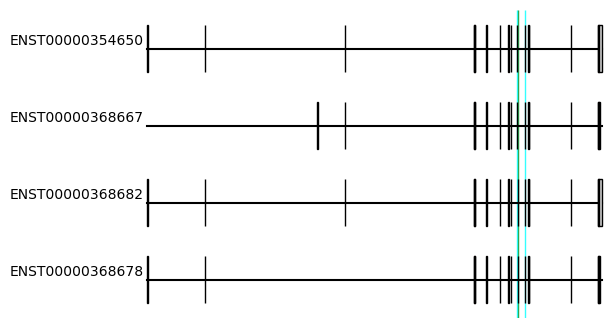

In [15]:

ax = plotter.plot_transcripts(data_sub['geneSymbol'], functional_threshold = 0.9)
ax.axvspan(spliced_region[0], spliced_region[1], color='green', alpha=0.8)
ax.axvspan(upstream_region[0], upstream_region[1], color='cyan', alpha=0.8)
ax.axvspan(downstream_region[0], downstream_region[1], color='cyan', alpha=0.8)

## Plot splice event

In [16]:
#get columns associated with ptm coordinates table
query = """PRAGMA table_info(ptm_coordinates);"""
plotter.conn.execute(query).fetchall()

[(0, 'Coordinate_ID', 'TEXT', 0, None, 1),
 (1, 'Chromosome', 'TEXT', 0, None, 0),
 (2, 'Strand', 'INT', 0, None, 0),
 (3, 'Gene_location_hg38', 'INT', 0, None, 0)]

In [ ]:
importlib.reload(plotting)d

<module 'plotting' from 'c:\\Users\\crowl\\OneDrive\\Documents\\GradSchool\\Research\\Splicing\\ExonPTMapper\\Convert_to_SQL\\plotting.py'>

In [98]:
data_sub

ID                                 27944
GeneID                ENSG00000010810.17
geneSymbol                           FYN
chr                                 chr6
strand                                 -
exonStart_0base                111700103
exonEnd                        111700268
upstreamES                     111699514
upstreamEE                     111699670
downstreamES                   111702884
downstreamEE                   111703034
ID.1                               27944
IJC_SAMPLE_1                       53,46
SJC_SAMPLE_1                         0,3
IJC_SAMPLE_2                       34,32
SJC_SAMPLE_2                         7,9
IncFormLen                           264
SkipFormLen                           99
PValue                          0.000052
FDR                              0.00197
IncLevel1                      1.0,0.852
IncLevel2                    0.646,0.571
IncLevelDifference                 0.317
Name: 18445, dtype: object

In [96]:
plotter = plotting.plotter('mapper.db')

In [17]:
plotter.plot_splice_event(data_sub, event_type = 'SE')